# Predicting Monthly Electricity Consumption

**Course:** Python for Data Analysis (CPSC-610-21)  
**Program:** Master of Data Analytics  
**Institution:** University of Niagara Falls  
**Term:** December 2025  
**Supervisor:** Omid Isfahanialamdari

---

## Team

- **Oladipo, Atinuke Imelda** — NF1030414  
- **Baskaran, Aravindhan** — NF1036831  
- **Nwajei, Pelaiah Oluchi** — NF1016881  
- **Rahman, Md Shahrukh** — NF1033216  

---

## Project Overview

This project analyzes electricity consumption across hundreds of properties in Ontario using data exported from the ENERGY STAR Portfolio Manager system.  
The dataset is provided in four CSV files describing:

- Property characteristics  
- Meters installed at each property  
- Monthly meter readings  
- Allocation of floor area to different use types  

Each row in the meter entries file represents a single monthly reading for one meter at one property.

---

## Objective

The main objective is to **predict monthly electricity consumption for buildings**, using only readings from **Electric – Grid** meters measured in **kWh**.  
The prediction target is the monthly usage column from the meter entries table; the other tables supply building, meter, and use-type attributes used as features in the models.

---

## Workflow

This notebook follows a complete data analytics pipeline:

1. **Data Loading & Cleaning** — Read all four CSV files, enforce correct data types, filter to Electric–Grid kWh records, identify and handle missing values and invalid records.  
2. **Data Integration** — Join meter entries with meter, property, and use-area tables to build a single meter-month analysis dataset.  
3. **Exploratory Data Analysis (EDA)** — Compute summary statistics, explore distributions and relationships, and examine correlations and seasonal patterns.  
4. **Visualization** — Histograms, boxplots, scatter plots, time-series line charts, and a correlation heatmap with consistent styling throughout.  
5. **Feature Engineering** — Derive energy intensity (kWh per ft²), calendar variables, and property-level use-area metrics.  
6. **Model Building** — Split data into train/test sets and fit a Ridge regression baseline and a Random Forest regressor, each inside a `Pipeline` with shared preprocessing.  
7. **Model Evaluation & Interpretation** — Compare models using R², MAE, and RMSE in the original kWh scale; perform hyperparameter tuning; analyze feature importances and residuals.  
8. **Conclusions & Next Steps** — Summarize findings, practical implications, limitations, and potential improvements.

All steps are documented with Markdown cells and inline comments to keep the workflow clear and reproducible.

## 1. Data Loading and Initial Inspection

In this section we set up the Python environment, load the four CSV files, and perform an initial sanity check on the raw data.

- Import all required libraries and adjust display options for easier reading in Jupyter.  
- Read `properties.csv`, `meters.csv`, `meter_entries.csv`, and `uses.csv` into DataFrames.  
- Display the first and last few rows of each table to verify that the files loaded correctly and the columns match the project description.  
- Print `.info()` and column-level missing-value counts to understand row counts, data types, and data quality issues before cleaning.

In [1]:
# ── Standard library & third-party imports ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Global plot style — applied once for the entire notebook
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# ── Load raw CSV files ────────────────────────────────────────────────────────
df_properties   = pd.read_csv("properties.csv")
df_meters       = pd.read_csv("meters.csv")
df_meter_entries = pd.read_csv("meter_entries.csv")
df_uses         = pd.read_csv("uses.csv")

# ── Quick previews ────────────────────────────────────────────────────────────
for name, df in [("Properties", df_properties), ("Meters", df_meters),
                 ("Meter Entries", df_meter_entries), ("Uses", df_uses)]:
    print(f"=== {name} — head ===")
    display(df.head())
    print(f"=== {name} — tail ===")
    display(df.tail())

# ── Structural info and null counts ──────────────────────────────────────────
for name, df in [("Properties", df_properties), ("Meters", df_meters),
                 ("Meter Entries", df_meter_entries), ("Uses", df_uses)]:
    print(f"\n=== {name}.info() ===")
    df.info()
    print(f"\nMissing values — {name}:")
    print(df.isna().sum())

=== Properties — head ===


,Property Name,Portfolio Manager ID,Street Address,City/Municipality,Postal Code,Property Type - Self-Selected,Gross Floor Area,Occupancy (%)
0,#11 Police Division - OLD,34999087,209 MAVETY ST,Toronto,M6P 2M1,Office,21119,100
1,#14 Police Division - OLD,34999088,150 HARRISON ST,Toronto,M6J 2A4,Office,24197,100
2,175 Memorial Park Ave,34999089,175 MEMORIAL PARK AVE,Toronto,M4J 2K5,Office,6394,100
3,18 Dyas Rd.,34999090,18 DYAS RD,North York,M3B 1V5,Office,73927,100
4,2 Civic Centre Court,34999091,2 CIVIC CENTRE CRT,Etobicoke,M9C 5A3,Office,46145,100


=== Properties — tail ===


,Property Name,Portfolio Manager ID,Street Address,City/Municipality,Postal Code,Property Type - Self-Selected,Gross Floor Area,Occupancy (%)
1755,Wilson Heights Pumping Station,35000816,279 WILSON HEIGHTS BLVD,North York,M3H 2V3,Other - Public Services,1,0
1756,Woodward & Highland,35000817,Woodward & Highland,Thornhill,L3T 1E9,Other - Public Services,1,0
1757,Works and Emergency Serv,35000818,Works & Emergency Serv,Toronto,M5V 3C6,Other - Public Services,1,100
1758,W.H. Johnston Pumping Station,35000836,1560 ROYAL YORK RD,Etobicoke,M9P 3C3,Drinking Water Treatment & Distribution,1744,100
1759,West Toronto Pumping Station,35000837,143 OLD WESTON RD,Toronto,M6N 3A4,Drinking Water Treatment & Distribution,7739,100


=== Meters — head ===


...

=== Uses — head ===


,Property Name,Portfolio Manager ID,Property Use Name,Use Type,Gross Floor Area for Use,Gross Floor Area Units,Gross Floor Area Temporary Value? (Y/N)
0,#11 Police Division - OLD,34999087,Building Use,Office,21119.0,Sq. Ft.,No
1,#14 Police Division - OLD,34999088,Building Use,Office,24197.0,Sq. Ft.,No
2,175 Memorial Park Ave,34999089,Building Use,Office,6394.0,Sq. Ft.,No
3,18 Dyas Rd.,34999090,Building Use,Office,73927.0,Sq. Ft.,No
4,2 Civic Centre Court,34999091,Building Use,Office,46145.0,Sq. Ft.,No


=== Uses — tail ===


,Property Name,Portfolio Manager ID,Property Use Name,Use Type,Gross Floor Area for Use,Gross Floor Area Units,Gross Floor Area Temporary Value? (Y/N)
1755,Island Water Treatment Plant,35000839,Building Use,Drinking Water Treatment & Distribution,64196.0,Sq. Ft.,No
1756,R.C. Harris Water Treatment Plant,35000840,Building Use,Drinking Water Treatment & Distribution,115368.0,Sq. Ft.,No
1757,R.L. Clark Water Treatment Plant,35000841,Building Use,Drinking Water Treatment & Distribution,401612.0,Sq. Ft.,No
1758,Riverside Common,35058174,Building Use,Other - Public Services,4833.0,Sq. Ft.,No
1759,One Yonge Community Centre,37103860,Building Use,Other - Recreation,51000.0,Sq. Ft.,No



=== Properties.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Property Name                  1760 non-null   object
 1   Portfolio Manager ID           1760 non-null   int64 
 2   Street Address                 1760 non-null   object
 3   City/Municipality              1760 non-null   object
 4   Postal Code                    1760 non-null   object
 5   Property Type - Self-Selected  1760 non-null   object
 6   Gross Floor Area               1760 non-null   int64 
 7   Occupancy (%)                  1760 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 110.1+ KB

Missing values — Properties:
Property Name                    0
Portfolio Manager ID             0
Street Address                   0
City/Municipality                0
Postal Code                      0
Property Type - Self

## 2. Data Type Cleaning and Schema Standardization

Before any analysis, we enforce appropriate data types across all four tables.

- **Date fields** in the meters and meter entries tables are converted to `datetime` with invalid formats coerced to `NaT`.  
- **`Cost ($)`** is cleaned by stripping currency symbols and commas, then cast to a numeric type.  
- **Identifier and size columns** (`Portfolio Manager ID`, `Portfolio Manager Meter ID`, `Meter Consumption ID`) are stored as `Int64` (nullable integer) to handle any NaN values safely before downstream filtering.  
  `Gross Floor Area` and `Occupancy (%)` are cast to `Int64` only after the rows used for modeling are confirmed to be non-null.  
- **Descriptive text fields** (property names, cities, postal codes, property types, meter names, use types, units) are converted to `category` to reduce memory and make later encoding explicit.  
- `.info()` is re-run on each DataFrame to confirm the updated schema.

In [2]:
# ── 1. Convert date columns to datetime ──────────────────────────────────────
for col in ["First Day of First Meter Entry", "Last Day of Last Meter Entry"]:
    df_meters[col] = pd.to_datetime(df_meters[col], errors="coerce")

for col in ["Start Date", "End Date"]:
    df_meter_entries[col] = pd.to_datetime(df_meter_entries[col], errors="coerce")

# ── 2. Clean and convert Cost ($) ────────────────────────────────────────────
df_meter_entries["Cost ($)"] = (
    df_meter_entries["Cost ($)"]
    .astype(str)
    .str.replace(r"[^0-9.\-]", "", regex=True)
    .replace("", pd.NA)
)
df_meter_entries["Cost ($)"] = pd.to_numeric(df_meter_entries["Cost ($)"], errors="coerce")

# ── 3. Identifier columns as nullable integers ────────────────────────────────
# Using pandas Int64 (capital I) so that NaN values are preserved as <NA>
# rather than silently overflowing when cast to numpy int64.
for col in ["Portfolio Manager ID"]:
    df_properties[col]    = pd.to_numeric(df_properties[col],    errors="coerce").astype("Int64")
    df_meters[col]        = pd.to_numeric(df_meters[col],         errors="coerce").astype("Int64")
    df_meter_entries[col] = pd.to_numeric(df_meter_entries[col],  errors="coerce").astype("Int64")
    df_uses[col]          = pd.to_numeric(df_uses[col],           errors="coerce").astype("Int64")

for col in ["Portfolio Manager Meter ID"]:
    df_meters[col]        = pd.to_numeric(df_meters[col],        errors="coerce").astype("Int64")
    df_meter_entries[col] = pd.to_numeric(df_meter_entries[col], errors="coerce").astype("Int64")

df_meter_entries["Meter Consumption ID"] = (
    pd.to_numeric(df_meter_entries["Meter Consumption ID"], errors="coerce").astype("Int64")
)

# ── 4. Categorical columns ────────────────────────────────────────────────────
cat_properties = ["Property Name", "City/Municipality", "Postal Code",
                  "Property Type - Self-Selected", "Street Address"]
cat_meters = ["Property Name", "Meter Name", "Meter Type", "Units"]
cat_meter_entries = ["Property Name", "Meter Name", "Meter Type", "Usage Units"]
cat_uses = ["Property Name", "Property Use Name", "Use Type",
            "Gross Floor Area Units", "Gross Floor Area Temporary Value? (Y/N)"]

for col in cat_properties:
    if col in df_properties.columns:
        df_properties[col] = df_properties[col].astype("category")

for col in cat_meters:
    if col in df_meters.columns:
        df_meters[col] = df_meters[col].astype("category")

for col in cat_meter_entries:
    if col in df_meter_entries.columns:
        df_meter_entries[col] = df_meter_entries[col].astype("category")

for col in cat_uses:
    if col in df_uses.columns:
        df_uses[col] = df_uses[col].astype("category")

# ── 5. Confirm updated schema ─────────────────────────────────────────────────
for name, df in [("Properties", df_properties), ("Meters", df_meters),
                 ("Meter Entries", df_meter_entries), ("Uses", df_uses)]:
    print(f"\n=== {name}.info() after type conversion ===")
    df.info()


=== Properties.info() after type conversion ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Property Name                  1760 non-null   category
 1   Portfolio Manager ID           1760 non-null   Int64   
 2   Street Address                 1760 non-null   category
 3   City/Municipality              1760 non-null   category
 4   Postal Code                    1760 non-null   category
 5   Property Type - Self-Selected  1760 non-null   category
 6   Gross Floor Area               1760 non-null   int64   
 7   Occupancy (%)                  1760 non-null   int64   
dtypes: Int64(1), category(5), int64(2)
memory usage: 257.5 KB

=== Meters.info() after type conversion ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2585 entries, 0 to 2584
Data columns (total 8 columns):
 #   Column          

## 3. Filtering to Electric–Grid kWh Records and Quality Checks

Here we focus the analysis on the subset that matches the project objective and verify its quality.

- Inspect unique values in `Meter Type` and `Usage Units` to confirm the exact labels present in the data.  
- Filter the meter entries table to **Electric – Grid** meters with **kWh (thousand Watt-hours)** units, creating `df_me_elec`.  
- Check the filtered table for missing values in key fields (IDs, dates, usage, and cost) and scan for NA-like placeholders.  
- Identify duplicate readings (same property, meter, start date, and end date) and flag records with negative usage or cost.  
- Run the same quality checks on the properties, meters, and uses tables.

In [3]:
# ── Inspect unique labels before filtering ───────────────────────────────────
print("Unique Meter Types:")
print(df_meter_entries["Meter Type"].unique())
print("\nUnique Usage Units:")
print(df_meter_entries["Usage Units"].unique())

# ── Filter to Electric - Grid, kWh ───────────────────────────────────────────
mask_elec = df_meter_entries["Meter Type"] == "Electric - Grid"
mask_kwh  = df_meter_entries["Usage Units"] == "kWh (thousand Watt-hours)"
df_me_elec = df_meter_entries[mask_elec & mask_kwh].copy()

print(f"\nRows before filter : {df_meter_entries.shape[0]:,}")
print(f"Rows after filter  : {df_me_elec.shape[0]:,}")

# ── Missing values in key columns ────────────────────────────────────────────
key_cols = ["Property Name", "Portfolio Manager ID", "Portfolio Manager Meter ID",
            "Start Date", "End Date", "Usage/Quantity", "Cost ($)"]
print("\nMissing values in filtered meter entries:")
print(df_me_elec[key_cols].isna().sum())

# ── NA-like text in categorical columns ──────────────────────────────────────
na_tokens = {"na", "n/a", "not available", "not applicable"}
for col in ["Meter Name", "Meter Type", "Usage Units"]:
    n = df_me_elec[col].astype(str).str.strip().str.lower().isin(na_tokens).sum()
    print(f"  '{col}' — NA-like text entries: {n}")

# ── Duplicate readings ────────────────────────────────────────────────────────
dup_cols = ["Portfolio Manager ID", "Portfolio Manager Meter ID", "Start Date", "End Date"]
dup_mask = df_me_elec.duplicated(subset=dup_cols, keep="first")
print(f"\nPotential duplicate records: {dup_mask.sum()}")
if dup_mask.any():
    display(df_me_elec.loc[dup_mask].head())

# ── Invalid values (negative usage / negative cost) ──────────────────────────
neg_usage = df_me_elec["Usage/Quantity"] < 0
neg_cost  = df_me_elec["Cost ($)"].notna() & (df_me_elec["Cost ($)"] < 0)
print(f"Negative usage rows: {neg_usage.sum()}")
print(f"Negative cost rows : {neg_cost.sum()}")

# ── Quality checks on the other three tables ──────────────────────────────────
for name, df in [("Properties", df_properties), ("Meters", df_meters), ("Uses", df_uses)]:
    print(f"\n=== {name} — missing values by column ===")
    print(df.isna().sum())
    text_cols = [c for c in df.columns if str(df[c].dtype) in ("object", "category")]
    for col in text_cols:
        n = df[col].astype(str).str.strip().str.lower().isin(na_tokens).sum()
        if n > 0:
            print(f"  '{col}' has {n} NA-like text entries.")

Unique Meter Types:
['Electric - Grid', 'Natural Gas', 'Average Influent Flow', 'District Steam', 'District Chilled Water - Other']
Categories (5, object): ['Average Influent Flow', 'District Chilled Water - Other', 'District Steam', 'Electric - Grid', 'Natural Gas']

Unique Usage Units:
['kWh (thousand Watt-hours)', 'cm (cubic meters)', 'Cubic Meters per Day', 'kLbs. (thousand pounds)', 'ton hours']
Categories (5, object): ['Cubic Meters per Day', 'cm (cubic meters)', 'kLbs. (thousand pounds)', 'kWh (thousand Watt-hours)', 'ton hours']

Rows before filter : 26,222
Rows after filter  : 18,109

Missing values in filtered meter entries:
Property Name                 0
Portfolio Manager ID          0
Portfolio Manager Meter ID    0
Start Date                    0
End Date                      0
Usage/Quantity                0
Cost ($)                      0
dtype: int64
  'Meter Name' — NA-like text entries: 0
  'Meter Type' — NA-like text entries: 0
  'Usage Units' — NA-like text entries

## 4. Domain-Specific Cleaning

Here we finalize the cleaning of the Electric–Grid subset and prepare the supporting tables for later joins.

- **Meter entries**: negative cost values are treated as billing corrections and set to 0; key fields are confirmed complete.  
- **Meters**: restricted to Electric–Grid / kWh; missing first/last entry dates are tracked with a Boolean flag.  
- **Uses**: records with missing floor-area information are flagged rather than dropped immediately.  
- **Uses flag column** (`Gross Floor Area Temporary Value? (Y/N)`): NA-like text values are normalized to `"Unknown"` and all responses are standardized to uppercase `Y` / `N`.

In [4]:
# ── 1. Clean meter entries ────────────────────────────────────────────────────
print(f"Rows before cleaning: {df_me_elec.shape[0]:,}")

# Negative cost rows are billing adjustments; set to 0
neg_cost_mask = df_me_elec["Cost ($)"].notna() & (df_me_elec["Cost ($)"] < 0)
print(f"Negative cost rows reset to 0: {neg_cost_mask.sum()}")
df_me_elec.loc[neg_cost_mask, "Cost ($)"] = 0.0

# Confirm key fields have no missing values
print("\nMissing values in key columns after cleaning:")
print(df_me_elec[["Property Name", "Portfolio Manager ID", "Portfolio Manager Meter ID",
                   "Start Date", "End Date", "Usage/Quantity"]].isna().sum())
print(f"Rows after cleaning: {df_me_elec.shape[0]:,}")

# ── 2. Restrict meters to Electric - Grid, kWh ───────────────────────────────
mask_m_elec = df_meters["Meter Type"] == "Electric - Grid"
mask_m_kwh  = df_meters["Units"]      == "kWh (thousand Watt-hours)"
df_meters_elec = df_meters[mask_m_elec & mask_m_kwh].copy()
print(f"\nMeters total: {df_meters.shape[0]}  →  Electric-Grid kWh: {df_meters_elec.shape[0]}")
print("Missing first/last entry dates in filtered meters:")
print(df_meters_elec[["First Day of First Meter Entry",
                       "Last Day of Last Meter Entry"]].isna().sum())

# ── 3. Flag uses records with missing floor-area information ─────────────────
df_uses["missing_area_info"] = (
    df_uses["Gross Floor Area for Use"].isna() |
    df_uses["Gross Floor Area Units"].isna()
)
print(f"\nUses rows with missing area info: {df_uses['missing_area_info'].sum()}")

# ── 4. Normalize the Y/N temporary-value flag ────────────────────────────────
col_flag = "Gross Floor Area Temporary Value? (Y/N)"
na_tokens = {"na", "n/a", "not available", "not applicable"}

flag_str = df_uses[col_flag].astype(str).str.strip()
na_like  = flag_str.str.lower().isin(na_tokens)
print(f"NA-like text entries in flag column: {na_like.sum()}")

flag_str = flag_str.where(~na_like, other="Unknown")
flag_str = flag_str.str.upper().replace({"YES": "Y", "NO": "N"})
df_uses[col_flag] = flag_str.astype("category")

Rows before cleaning: 18,109
Negative cost rows reset to 0: 15

Missing values in key columns after cleaning:
Property Name                 0
Portfolio Manager ID          0
Portfolio Manager Meter ID    0
Start Date                    0
End Date                      0
Usage/Quantity                0
dtype: int64
Rows after cleaning: 18,109

Meters total: 2585  →  Electric-Grid kWh: 1728
Missing first/last entry dates in filtered meters:
First Day of First Meter Entry    63
Last Day of Last Meter Entry      63
dtype: int64

Uses rows with missing area info: 171
NA-like text entries in flag column: 171


## 5. Building the Integrated Analysis Dataset

We now align all four tables around the cleaned Electric–Grid meter entries to build the main modeling dataset.

- Identify the meter IDs and property IDs that appear in the filtered readings and restrict the other tables accordingly.  
- Add a `missing_first_last_date` flag to track Electric–Grid meters with incomplete date coverage.  
- **Join** meter entries with per-meter metadata (meter name, date coverage flag) on `Portfolio Manager ID` + `Portfolio Manager Meter ID`.  
- **Join** property characteristics (location, property type, gross floor area, occupancy) to give each meter-month record its building context.  
- **Aggregate** the uses table to compute `total_use_area` and `n_use_types` per property, then merge these into the main table.  
- Confirm that key fields contain no missing values in the resulting `df_me_final`.

In [5]:
# ── 1. Align supporting tables to the filtered meter entries ─────────────────
used_meter_ids    = df_me_elec["Portfolio Manager Meter ID"].unique()
used_property_ids = df_me_elec["Portfolio Manager ID"].unique()

df_meters_elec_used = df_meters_elec[
    df_meters_elec["Portfolio Manager Meter ID"].isin(used_meter_ids)
].copy()

# Flag meters with incomplete date coverage
df_meters_elec_used["missing_first_last_date"] = (
    df_meters_elec_used["First Day of First Meter Entry"].isna() |
    df_meters_elec_used["Last Day of Last Meter Entry"].isna()
)

df_properties_used = df_properties[
    df_properties["Portfolio Manager ID"].isin(used_property_ids)
].copy()
df_uses_used = df_uses[
    df_uses["Portfolio Manager ID"].isin(used_property_ids)
].copy()

print(f"Meters in use  : {df_meters_elec_used.shape[0]}")
print(f"Properties     : {df_properties_used.shape[0]}")
print(f"Use records    : {df_uses_used.shape[0]}")

# ── 2. Join meter entries with meter metadata ─────────────────────────────────
meter_meta_cols = [
    "Portfolio Manager ID", "Portfolio Manager Meter ID",
    "Meter Name", "First Day of First Meter Entry",
    "Last Day of Last Meter Entry", "missing_first_last_date"
]
df_me_with_m = df_me_elec.merge(
    df_meters_elec_used[meter_meta_cols],
    on=["Portfolio Manager ID", "Portfolio Manager Meter ID"],
    how="left",
    suffixes=("", "_meter")
)
print(f"\nShape after joining meter metadata : {df_me_with_m.shape}")

# ── 3. Join property characteristics ─────────────────────────────────────────
props_cols = ["Portfolio Manager ID", "Property Name", "City/Municipality",
              "Postal Code", "Property Type - Self-Selected",
              "Gross Floor Area", "Occupancy (%)"]
props_slice = (
    df_properties_used[props_cols]
    .drop_duplicates(subset=["Portfolio Manager ID"])
)
df_me_with_mp = df_me_with_m.merge(
    props_slice,
    on="Portfolio Manager ID",
    how="left",
    suffixes=("", "_prop")
)
print(f"Shape after joining property info   : {df_me_with_mp.shape}")

# ── 4. Aggregate use-area at property level ───────────────────────────────────
uses_valid = df_uses_used[~df_uses_used["missing_area_info"]].copy()
uses_summary = (
    uses_valid
    .groupby("Portfolio Manager ID", as_index=False)
    .agg(
        total_use_area=("Gross Floor Area for Use", "sum"),
        n_use_types=("Use Type", "nunique")
    )
)
print(f"Properties with use-area summary    : {uses_summary.shape[0]}")

# ── 5. Build df_me_final ──────────────────────────────────────────────────────
df_me_final = df_me_with_mp.merge(uses_summary, on="Portfolio Manager ID", how="left")
print(f"\nFinal analysis table shape: {df_me_final.shape}")
display(df_me_final.head())

# ── 6. Sanity check: no missing values in core fields ────────────────────────
core_fields = ["Portfolio Manager ID", "Portfolio Manager Meter ID",
               "Start Date", "End Date", "Usage/Quantity",
               "Property Name", "Property Type - Self-Selected", "Gross Floor Area"]
print("\nMissing values in core analysis fields:")
print(df_me_final[core_fields].isna().sum())

Meters in use  : 1650
Properties     : 1650
Use records    : 1650

Shape after joining meter metadata : (18109, 15)
Shape after joining property info   : (18109, 21)
Properties with use-area summary    : 1484

Final analysis table shape: (18109, 23)


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Meter Consumption ID,Start Date,End Date,Usage/Quantity,Usage Units,Cost ($),Meter Name_meter,First Day of First Meter Entry,Last Day of Last Meter Entry,missing_first_last_date,Property Name_prop,City/Municipality,Postal Code,Property Type - Self-Selected,Gross Floor Area,Occupancy (%),total_use_area,n_use_types
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01,2022-02-01,42876.27,kWh (thousand Watt-hours),5775.70,AUTO_#13 Police Division-Electric,2010-01-01,2024-09-01,False,#13 Police Division,Toronto,M6C 3Z4,Police Station,20344,100,20344.0,1.0
1,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01,2022-03-01,39721.72,kWh (thousand Watt-hours),5377.67,AUTO_#13 Police Division-Electric,2010-01-01,2024-09-01,False,#13 Police Division,Toronto,M6C 3Z4,Police Station,20344,100,20344.0,1.0
2,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01,2022-04-01,41278.04,kWh (thousand Watt-hours),5611.00,AUTO_#13 Police Division-Electric,2010-01-01,2024-09-01,False,#13 Police Division,Toronto,M6C 3Z4,Police Station,20344,100,20344.0,1.0
3,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527472,2022-04-01,2022-05-01,37111.95,kWh (thousand Watt-hours),4989.06,AUTO_#13 Police Division-Electric,2010-01-01,2024-09-01,False,#13 Police Division,Toronto,M6C 3Z4,Police Station,20344,100,20344.0,1.0
4,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527473,2022-05-01,2022-06-01,41778.27,kWh (thousand Watt-hours),5984.66,AUTO_#13 Police Division-Electric,2010-01-01,2024-09-01,False,#13 Police Division,Toronto,M6C 3Z4,Police Station,20344,100,20344.0,1.0



Missing values in core analysis fields:
Portfolio Manager ID             0
Portfolio Manager Meter ID       0
Start Date                       0
End Date                         0
Usage/Quantity                   0
Property Name                    0
Property Type - Self-Selected    0
Gross Floor Area                 0
dtype: int64


## 6. Exploratory Data Analysis

### 6.1 Dataset Structure and Summary Statistics

We begin EDA by checking the overall shape and composition of `df_me_final`.

- Report the number of rows and columns and list all data types.  
- Compute descriptive statistics for **numeric** variables (usage, cost, floor area, occupancy).  
- Compute summary statistics for **categorical** variables (property type, city, usage units) to see cardinalities and most-common values.

In [6]:
print(f"df_me_final shape: {df_me_final.shape}")
print("\nColumn dtypes:")
print(df_me_final.dtypes)

print("\nNumeric summary:")
display(df_me_final.select_dtypes(include="number").describe())

print("\nCategorical summary:")
display(df_me_final.select_dtypes(exclude="number").describe(include="all"))

df_me_final shape: (18109, 23)

Column dtypes:
Property Name                           category
Portfolio Manager ID                       Int64
Portfolio Manager Meter ID                 Int64
Meter Name                              category
Meter Type                              category
Meter Consumption ID                       Int64
Start Date                        datetime64[ns]
End Date                          datetime64[ns]
Usage/Quantity                           float64
Usage Units                             category
Cost ($)                                 float64
Meter Name_meter                        category
First Day of First Meter Entry    datetime64[ns]
Last Day of Last Meter Entry      datetime64[ns]
missing_first_last_date                     bool
Property Name_prop                      category
City/Municipality                       category
Postal Code                             category
Property Type - Self-Selected           category
Gross Floor Area      

,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Consumption ID,Usage/Quantity,Cost ($),Gross Floor Area,Occupancy (%),total_use_area,n_use_types
count,18109.0,18109.0,18109.0,1.810900e+04,1.810900e+04,18109.000000,18109.000000,16296.000000,16296.0
mean,34999961.877519,190110321.796897,8451535166.794522,7.597673e+04,1.096852e+04,17586.799271,93.804186,16186.260002,1.0
std,508.269991,42949.674603,8907.00885,4.083190e+05,5.522264e+04,63834.379641,24.108617,61165.694917,0.0
min,34999087.0,189947870.0,8451519101.0,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000,1.0
25%,34999518.0,190083469.0,8451527269.0,5.376500e+02,1.177000e+02,1.000000,100.000000,0.000000,1.0
50%,34999960.0,190109997.0,8451535655.0,4.321070e+03,7.207200e+02,314.000000,100.000000,231.000000,1.0
75%,35000394.0,190122652.0,8451543200.0,2.423638e+04,3.787690e+03,11496.000000,100.000000,9160.000000,1.0
max,35000841.0,190190814.0,8451549551.0,1.199675e+07,1.401877e+06,986748.000000,100.000000,986748.000000,1.0



Categorical summary:


,Property Name,Meter Name,Meter Type,Start Date,End Date,Usage Units,Meter Name_meter,First Day of First Meter Entry,Last Day of Last Meter Entry,missing_first_last_date,Property Name_prop,City/Municipality,Postal Code,Property Type - Self-Selected
count,18109,18109,18109,18109,18109,18109,18109,18109,18109,18109,18109,18109,18109,18109
unique,1650,1650,1,NaN,NaN,1,1650,NaN,NaN,1,1650,12,1389,15
top,Zooview Park,AUTO_Zooview Park-Electric,Electric - Grid,NaN,NaN,kWh (thousand Watt-hours),AUTO_Zion School House-Electric,NaN,NaN,False,Willowridge Early Learning & Child Care Centre,Toronto,M5V 3C6,Other - Public Services
freq,11,11,18109,NaN,NaN,18109,11,NaN,NaN,18109,11,9458,165,8923
mean,NaN,NaN,NaN,2022-06-01 05:52:39.865260288,2022-07-01 13:53:40.299298816,NaN,NaN,2011-07-14 12:03:37.085427456,2024-06-28 09:12:20.118173184,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2022-01-01 00:00:00,2022-01-07 00:00:00,NaN,NaN,2010-01-01 00:00:00,2022-01-24 00:00:00,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2022-03-01 00:00:00,2022-04-01 00:00:00,NaN,NaN,2010-01-01 00:00:00,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2022-06-01 00:00:00,2022-07-01 00:00:00,NaN,NaN,2010-01-01 00:00:00,2024-10-01 00:00:00,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2022-09-01 00:00:00,2022-10-01 00:00:00,NaN,NaN,2010-01-01 00:00:00,2024-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,2022-11-01 00:00:00,2022-12-01 00:00:00,NaN,NaN,2022-02-01 00:00:00,2024-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN


### 6.2 Derived Features: Energy Intensity and Calendar Variables

To support analysis and modeling, we engineer three additional columns:

- **`kwh_per_ft2`** — monthly electricity usage per square foot (energy intensity).  
- **`year`** and **`month`** — extracted from `Start Date` to study trends and seasonality.

In [7]:
# Energy intensity: kWh consumed per square foot in the billing period
df_me_final["kwh_per_ft2"] = df_me_final["Usage/Quantity"] / df_me_final["Gross Floor Area"]

# Calendar features
df_me_final["year"]  = df_me_final["Start Date"].dt.year
df_me_final["month"] = df_me_final["Start Date"].dt.month

print(df_me_final[["Usage/Quantity", "Gross Floor Area", "kwh_per_ft2", "year", "month"]].head(10))

   Usage/Quantity  Gross Floor Area  kwh_per_ft2  year  month
0        42876.27             20344     2.107563  2022      1
1        39721.72             20344     1.952503  2022      2
2        41278.04             20344     2.029003  2022      3
3        37111.95             20344     1.824221  2022      4
4        41778.27             20344     2.053592  2022      5
5        43191.93             20344     2.123080  2022      6
6        51529.45             20344     2.532907  2022      7
7        52583.64             20344     2.584725  2022      8
8        34396.96             20344     1.690767  2022      9
9        30086.82             20344     1.478904  2022     10


### 6.3 Distribution of Monthly Usage and Skewness

Monthly kWh consumption is expected to be strongly right-skewed. We quantify the skewness, then apply a `log1p` transform to both usage and intensity to obtain more symmetric, model-friendly distributions.

In [8]:
skew_usage     = df_me_final["Usage/Quantity"].skew()
skew_intensity = df_me_final["kwh_per_ft2"].skew()
print(f"Skewness — Usage/Quantity : {skew_usage:.2f}")
print(f"Skewness — kwh_per_ft2   : {skew_intensity:.2f}")

# Log-transformed features (log1p handles zero values safely)
df_me_final["log_kwh"]         = np.log1p(df_me_final["Usage/Quantity"])
df_me_final["log_kwh_per_ft2"] = np.log1p(df_me_final["kwh_per_ft2"])

skew_log_kwh       = df_me_final["log_kwh"].skew()
skew_log_intensity = df_me_final["log_kwh_per_ft2"].skew()
print(f"\nSkewness after log transform — log_kwh       : {skew_log_kwh:.2f}")
print(f"Skewness after log transform — log_kwh_per_ft2: {skew_log_intensity:.2f}")

Skewness — Usage/Quantity : 15.69
Skewness — kwh_per_ft2   : 11.22

Skewness after log transform — log_kwh       : -0.39
Skewness after log transform — log_kwh_per_ft2: 1.30


### 6.4 Raw vs. Log-Transformed Distributions

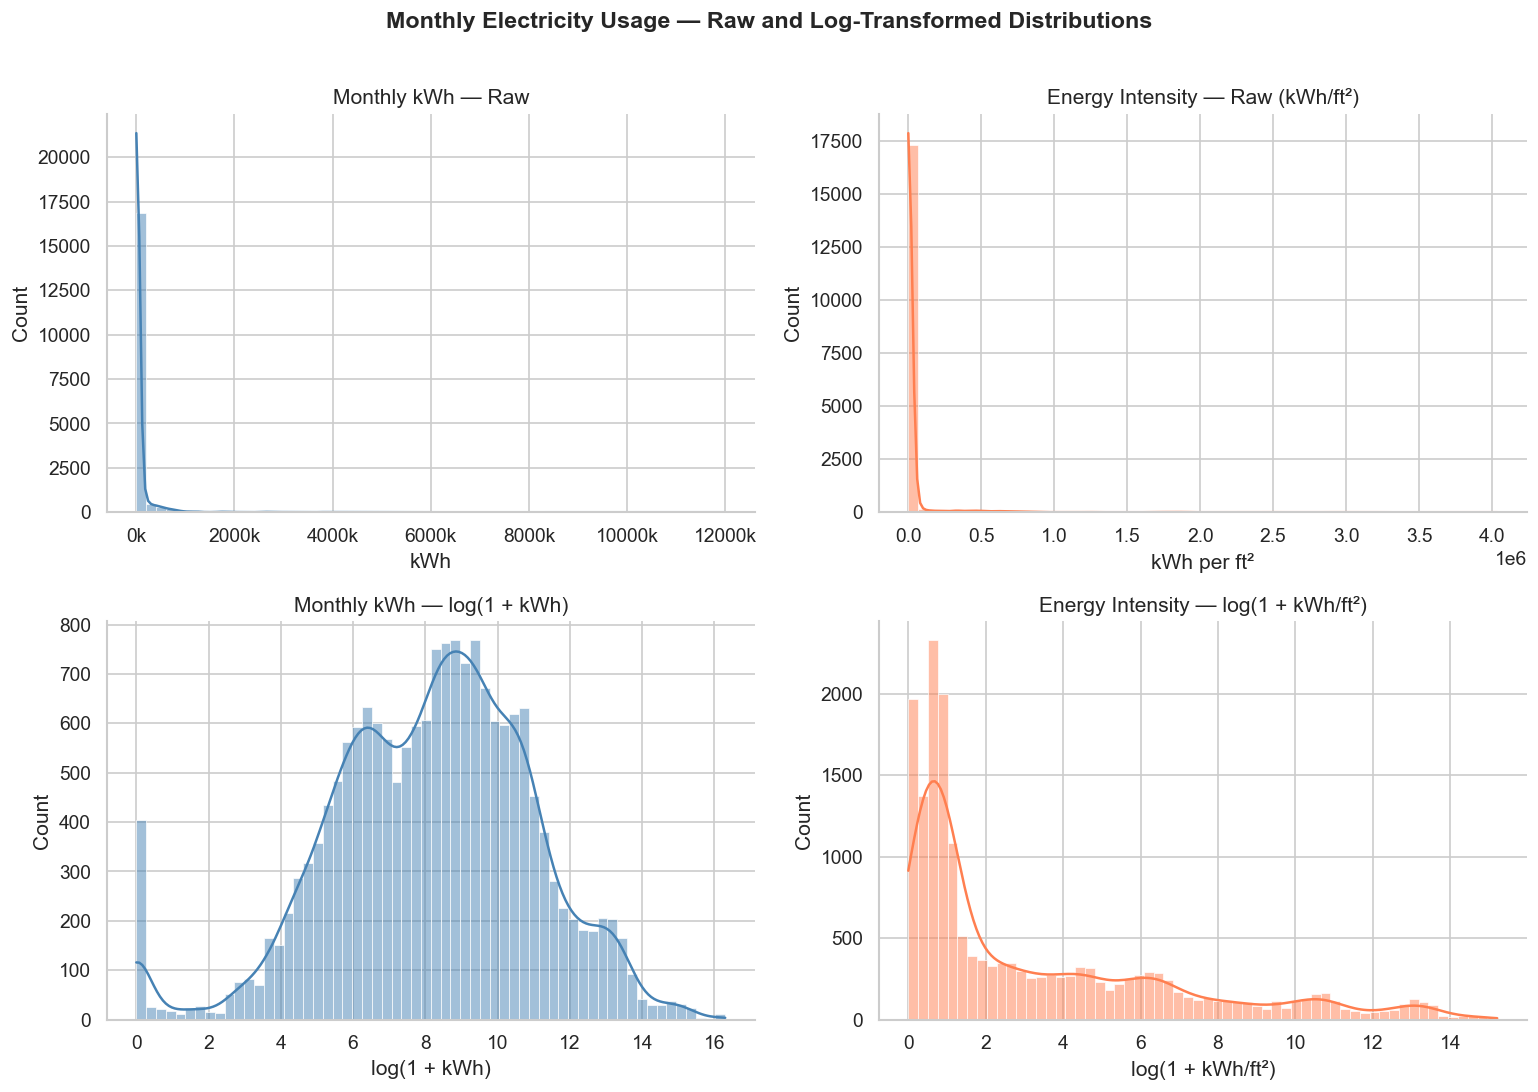

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Monthly Electricity Usage — Raw and Log-Transformed Distributions",
             fontsize=14, fontweight="bold", y=1.01)

# Raw usage
sns.histplot(df_me_final["Usage/Quantity"], bins=60, kde=True,
             ax=axes[0, 0], color="steelblue", edgecolor="white", linewidth=0.4)
axes[0, 0].set_title("Monthly kWh — Raw")
axes[0, 0].set_xlabel("kWh")
axes[0, 0].set_ylabel("Count")
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

# Raw intensity
sns.histplot(df_me_final["kwh_per_ft2"].dropna(), bins=60, kde=True,
             ax=axes[0, 1], color="coral", edgecolor="white", linewidth=0.4)
axes[0, 1].set_title("Energy Intensity — Raw (kWh/ft²)")
axes[0, 1].set_xlabel("kWh per ft²")
axes[0, 1].set_ylabel("Count")

# Log usage
sns.histplot(df_me_final["log_kwh"], bins=60, kde=True,
             ax=axes[1, 0], color="steelblue", edgecolor="white", linewidth=0.4)
axes[1, 0].set_title("Monthly kWh — log(1 + kWh)")
axes[1, 0].set_xlabel("log(1 + kWh)")
axes[1, 0].set_ylabel("Count")

# Log intensity
sns.histplot(df_me_final["log_kwh_per_ft2"].dropna(), bins=60, kde=True,
             ax=axes[1, 1], color="coral", edgecolor="white", linewidth=0.4)
axes[1, 1].set_title("Energy Intensity — log(1 + kWh/ft²)")
axes[1, 1].set_xlabel("log(1 + kWh/ft²)")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### 6.5 Energy Intensity by Property Type

We examine how log-transformed intensity (`log_kwh_per_ft2`) varies across the ten most frequently observed property types, and compare raw intensity before the transform.

C:\Users\15197\AppData\Local\Temp\ipykernel_9396\4200321280.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x="Property Type - Self-Selected", y="log_kwh_per_ft2",


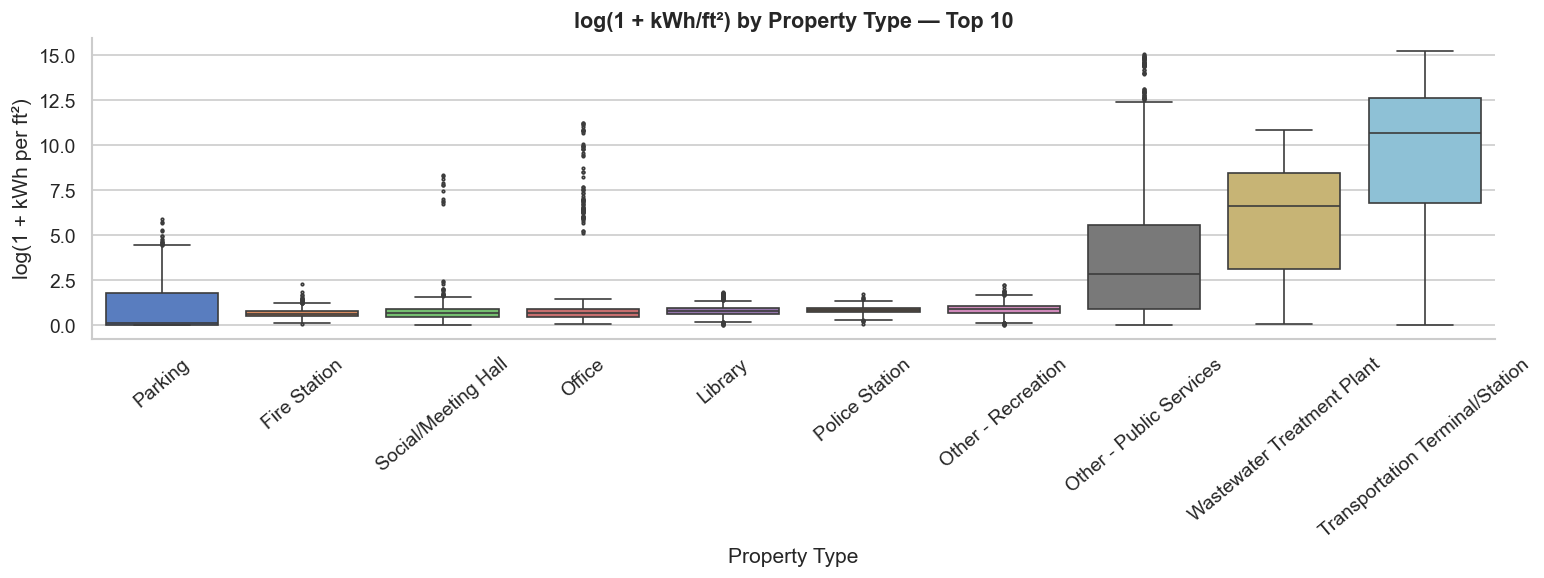

In [10]:
top_types = (
    df_me_final["Property Type - Self-Selected"]
    .value_counts()
    .head(10)
    .index
)
df_top = df_me_final[df_me_final["Property Type - Self-Selected"].isin(top_types)].copy()

# Sort by median log intensity for a more informative ordering
order = (
    df_top.groupby("Property Type - Self-Selected", observed=True)["log_kwh_per_ft2"]
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df_top, x="Property Type - Self-Selected", y="log_kwh_per_ft2",
            order=order, palette="muted", flierprops=dict(marker=".", markersize=3),
            ax=ax)
ax.set_title("log(1 + kWh/ft²) by Property Type — Top 10", fontsize=13, fontweight="bold")
ax.set_xlabel("Property Type")
ax.set_ylabel("log(1 + kWh per ft²)")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

### 6.6 Monthly kWh vs. Gross Floor Area (Log–Log)

We visualize the relationship between building size and electricity consumption on log–log axes to see how the two scale together across the wide range of property sizes in the portfolio.

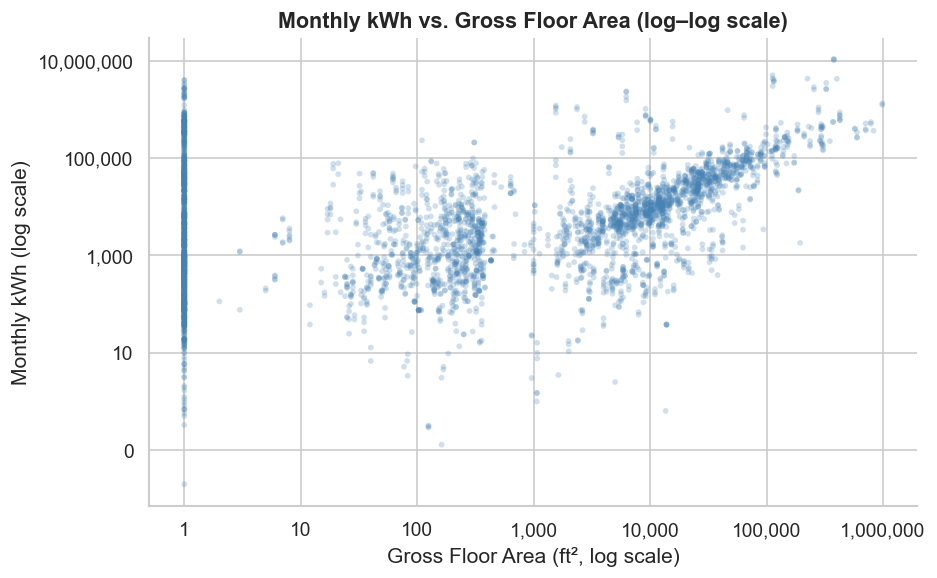

In [11]:
sample = df_me_final.sample(min(4000, len(df_me_final)), random_state=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    sample["Gross Floor Area"], sample["Usage/Quantity"],
    alpha=0.25, s=12, color="steelblue", edgecolors="none"
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Monthly kWh vs. Gross Floor Area (log–log scale)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Gross Floor Area (ft², log scale)")
ax.set_ylabel("Monthly kWh (log scale)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

### 6.7 Seasonal Pattern in Monthly Electricity Use

We group all meter-month records by calendar month and compute the mean (and 95 % confidence interval) of monthly kWh to reveal seasonal demand patterns.

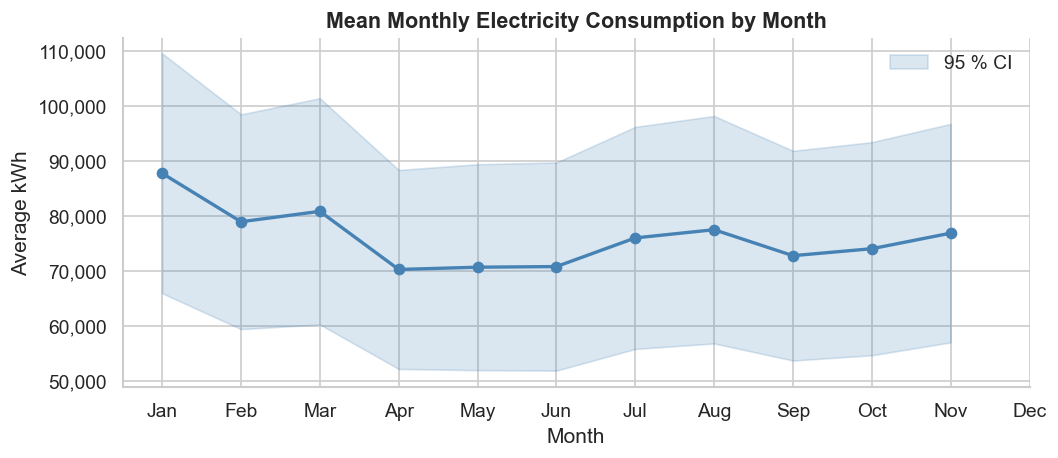

In [12]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_stats = (
    df_me_final
    .groupby("month")["Usage/Quantity"]
    .agg(mean="mean", sem="sem")
    .reset_index()
)
monthly_stats["ci95"] = 1.96 * monthly_stats["sem"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly_stats["month"], monthly_stats["mean"],
        marker="o", linewidth=2, color="steelblue", zorder=3)
ax.fill_between(
    monthly_stats["month"],
    monthly_stats["mean"] - monthly_stats["ci95"],
    monthly_stats["mean"] + monthly_stats["ci95"],
    alpha=0.2, color="steelblue", label="95 % CI"
)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title("Mean Monthly Electricity Consumption by Month",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Average kWh")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 6.8 Correlation Heatmap of Key Numeric Features

We compute pairwise Pearson correlations among the core quantitative variables to identify which features are most strongly associated with monthly electricity consumption and which may be collinear.

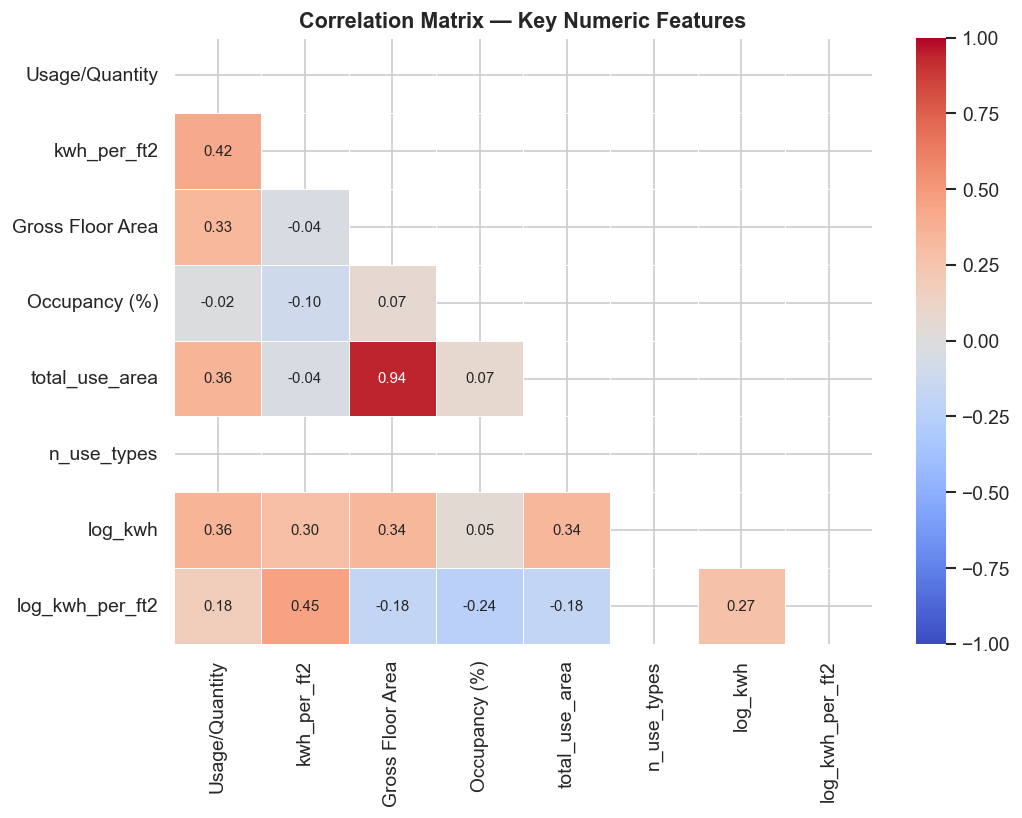

In [13]:
num_cols = ["Usage/Quantity", "kwh_per_ft2", "Gross Floor Area",
            "Occupancy (%)", "total_use_area", "n_use_types",
            "log_kwh", "log_kwh_per_ft2"]

corr = df_me_final[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # mask upper triangle

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 9},
    ax=ax
)
ax.set_title("Correlation Matrix — Key Numeric Features",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Modeling

### 7.1 Preparing the Modeling Dataset

Before fitting models, we create a dedicated copy and finalize the feature and target definitions.

- **Outlier clipping**: cap the top 0.5 % of both `Usage/Quantity` and `kwh_per_ft2` to reduce the influence of extreme values without discarding data.  
- **Target variable**: `log_kwh = log(1 + Usage/Quantity)` — the log transform stabilizes variance and produces a more Gaussian error distribution.  
- **Features**: year, month, gross floor area, occupancy, property type, city, total use area, number of use types, and a flag for missing meter date coverage.  
- Rows with any missing values in these fields are dropped, and the resulting shape is reported.

In [14]:
df_me_model = df_me_final.copy()

# Cap extreme values at the 99.5th percentile
for col in ["Usage/Quantity", "kwh_per_ft2"]:
    upper = df_me_model[col].quantile(0.995)
    df_me_model[col] = df_me_model[col].clip(upper=upper)

# Recompute log target after clipping
df_me_model["log_kwh"] = np.log1p(df_me_model["Usage/Quantity"])

# Feature and target definitions
FEATURE_COLS = [
    "year", "month",
    "Gross Floor Area", "Occupancy (%)",
    "Property Type - Self-Selected", "City/Municipality",
    "total_use_area", "n_use_types",
    "missing_first_last_date",
]
TARGET_COL = "log_kwh"

df_model = df_me_model[FEATURE_COLS + [TARGET_COL]].dropna()
print(f"Modeling dataset shape: {df_model.shape}")
print(f"Rows dropped (missing features): {len(df_me_model) - len(df_model):,}")

Modeling dataset shape: (16296, 10)
Rows dropped (missing features): 1,813


### 7.2 Train–Test Split and Model Pipelines

We split the dataset 80/20, then build two `Pipeline` objects that share a common `ColumnTransformer` preprocessor:

- **Numeric features** (`year`, `month`, floor area, occupancy, use-area metrics) are standardized with `StandardScaler`.  
- **Categorical features** (property type, city, missing-date flag) are one-hot encoded; unseen categories at test time are silently ignored.  

**Model 1 — Ridge regression** provides a regularized linear baseline.  
**Model 2 — Random Forest** captures nonlinear interactions and serves as the primary model.

In [15]:
# ── Train / test split ────────────────────────────────────────────────────────
X = df_model.drop(columns=[TARGET_COL])
y = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print(f"Training rows : {X_train.shape[0]:,}")
print(f"Test rows     : {X_test.shape[0]:,}")

# ── Shared preprocessing ──────────────────────────────────────────────────────
numeric_features = ["year", "month", "Gross Floor Area", "Occupancy (%)",
                    "total_use_area", "n_use_types"]
categorical_features = ["Property Type - Self-Selected", "City/Municipality",
                        "missing_first_last_date"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(),                          numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"),    categorical_features),
])

# ── Model 1: Ridge regression ─────────────────────────────────────────────────
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor",    Ridge(alpha=1.0)),
])
ridge_pipeline.fit(X_train, y_train)
print(f"\nRidge  — train R²: {ridge_pipeline.score(X_train, y_train):.4f}"
      f"   test R²: {ridge_pipeline.score(X_test, y_test):.4f}")

# ── Model 2: Random Forest ────────────────────────────────────────────────────
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor",    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
])
rf_pipeline.fit(X_train, y_train)
print(f"RF     — train R²: {rf_pipeline.score(X_train, y_train):.4f}"
      f"   test R²: {rf_pipeline.score(X_test, y_test):.4f}")

Training rows : 13,036
Test rows     : 3,260

Ridge  — train R²: 0.3432   test R²: 0.3417
RF     — train R²: 0.7162   test R²: 0.6535


### 7.3 Model Evaluation in Original kWh Units

Because the models are trained on the log scale, we back-transform both predictions and true values with `expm1` before computing error metrics.  
MAE and RMSE are reported in kWh so results have a practical, interpretable magnitude.

In [16]:
def evaluate_kwh(model, X_tr, y_tr, X_te, y_te, label="Model"):
    """Evaluate a log-space model; report MAE and RMSE in original kWh units."""
    y_tr_pred_kwh = np.expm1(model.predict(X_tr))
    y_te_pred_kwh = np.expm1(model.predict(X_te))
    y_tr_true_kwh = np.expm1(y_tr)
    y_te_true_kwh = np.expm1(y_te)

    results = {
        "Train MAE (kWh)":  mean_absolute_error(y_tr_true_kwh, y_tr_pred_kwh),
        "Test  MAE (kWh)":  mean_absolute_error(y_te_true_kwh, y_te_pred_kwh),
        "Train RMSE (kWh)": np.sqrt(mean_squared_error(y_tr_true_kwh, y_tr_pred_kwh)),
        "Test  RMSE (kWh)": np.sqrt(mean_squared_error(y_te_true_kwh, y_te_pred_kwh)),
        "Train R²":         r2_score(y_tr_true_kwh, y_tr_pred_kwh),
        "Test  R²":         r2_score(y_te_true_kwh, y_te_pred_kwh),
    }
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    for k, v in results.items():
        print(f"  {k:<22}: {v:>14,.1f}" if "kWh" in k else f"  {k:<22}: {v:>14.4f}")
    return results

ridge_metrics = evaluate_kwh(ridge_pipeline, X_train, y_train, X_test, y_test, "Ridge Regression")
rf_metrics    = evaluate_kwh(rf_pipeline,    X_train, y_train, X_test, y_test, "Random Forest")


────────────────────────────────────────
  Ridge Regression
────────────────────────────────────────
  Train MAE (kWh)       :    1,141,369.5
  Test  MAE (kWh)       :    1,694,318.7
  Train RMSE (kWh)      :   39,641,337.2
  Test  RMSE (kWh)      :   48,668,676.8
  Train R²              :    -21965.4317
  Test  R²              :    -27108.1266

────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  Train MAE (kWh)       :       28,592.3
  Test  MAE (kWh)       :       38,683.7
  Train RMSE (kWh)      :      169,546.0
  Test  RMSE (kWh)      :      204,970.7
  Train R²              :         0.5982
  Test  R²              :         0.5192


### 7.4 Hyperparameter Tuning — Random Forest

We use `GridSearchCV` with 3-fold cross-validation to search over the number of trees, maximum depth, and minimum samples per leaf.  
The best configuration is retrieved and re-evaluated against both the train and test sets.

In [17]:
# Build a fresh pipeline for the grid search to avoid state from the earlier fit
rf_pipeline_gs = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor",    RandomForestRegressor(random_state=42, n_jobs=-1)),
])

param_grid = {
    "regressor__n_estimators":    [100, 200],
    "regressor__max_depth":       [None, 10, 20],
    "regressor__min_samples_leaf": [1, 5, 10],
}

rf_grid = GridSearchCV(
    rf_pipeline_gs,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, y_train)

print(f"\nBest parameters  : {rf_grid.best_params_}")
print(f"Best CV R² (log) : {rf_grid.best_score_:.4f}")

best_rf_model = rf_grid.best_estimator_
tuned_metrics = evaluate_kwh(best_rf_model, X_train, y_train, X_test, y_test,
                              "Tuned Random Forest")

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best parameters  : {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 200}
Best CV R² (log) : 0.6342

────────────────────────────────────────
  Tuned Random Forest
────────────────────────────────────────
  Train MAE (kWh)       :       28,592.3
  Test  MAE (kWh)       :       38,683.7
  Train RMSE (kWh)      :      169,546.0
  Test  RMSE (kWh)      :      204,970.7
  Train R²              :         0.5982
  Test  R²              :         0.5192


### 7.5 Feature Importance

We extract the mean impurity-decrease importances from the tuned Random Forest and reconstruct the full feature name list (numeric features + one-hot encoded category names) to identify the most influential predictors.

In [18]:
# Extract components from the tuned pipeline
fitted_rf  = best_rf_model.named_steps["regressor"]
fitted_ohe = best_rf_model.named_steps["preprocessor"].named_transformers_["cat"]

# Reconstruct feature names after preprocessing
cat_feature_names = fitted_ohe.get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(cat_feature_names)

importances = (
    pd.Series(fitted_rf.feature_importances_, index=all_feature_names)
    .sort_values(ascending=False)
)

print("Top 20 feature importances:")
display(importances.head(20).to_frame("importance").style.format("{:.4f}"))

Top 20 feature importances:


,importance
Gross Floor Area,0.3435
Property Type - Self-Selected_Other - Public Services,0.3059
total_use_area,0.1483
month,0.0507
Occupancy (%),0.0313
Property Type - Self-Selected_Drinking Water Treatment & Distribution,0.0253
Property Type - Self-Selected_Transportation Terminal/Station,0.0185
City/Municipality_Scarborough,0.0177
City/Municipality_Etobicoke,0.0156
City/Municipality_East York,0.0121


### 7.6 Feature Importance Chart

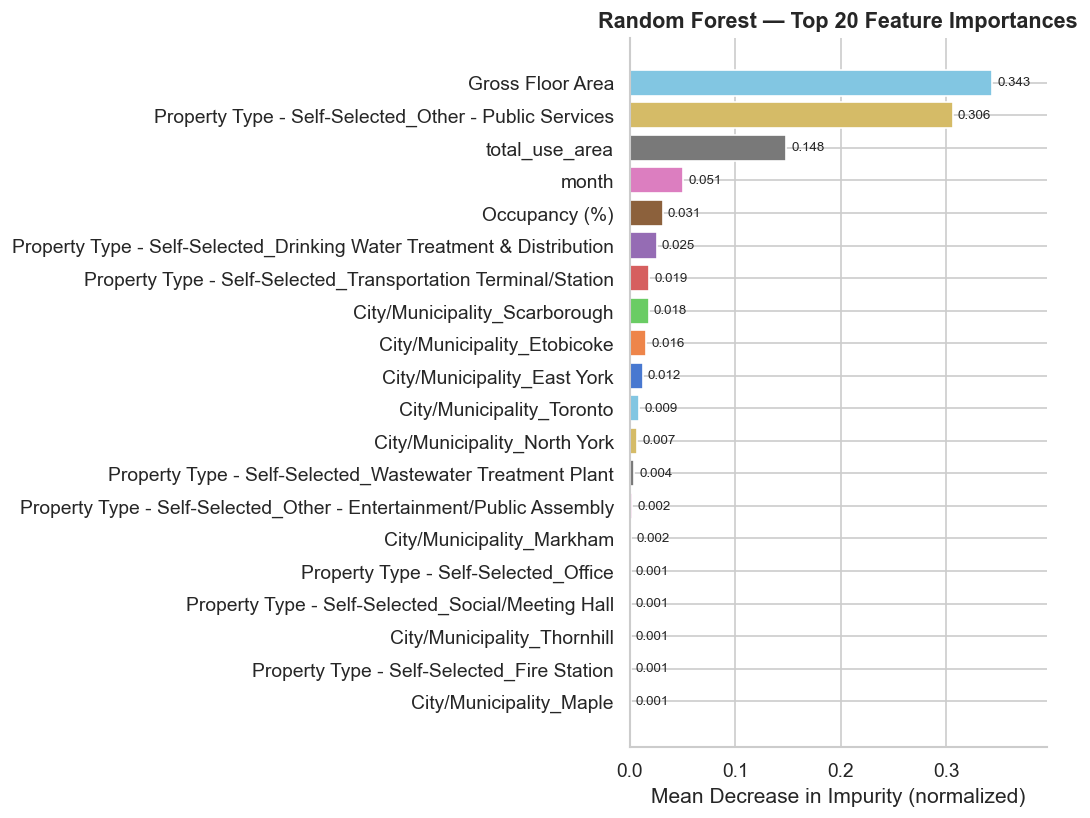

In [19]:
top_n = 20
top_imp = importances.head(top_n).iloc[::-1]   # reverse so highest is at top

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top_imp.index, top_imp.values,
               color=sns.color_palette("muted", top_n), edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.set_title(f"Random Forest — Top {top_n} Feature Importances",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mean Decrease in Impurity (normalized)")
ax.set_xlim(0, top_imp.values.max() * 1.15)
plt.tight_layout()
plt.show()

### 7.7 Residual Analysis

We examine the test-set residuals (actual − predicted, in kWh) to assess goodness-of-fit and identify any systematic patterns such as heteroscedasticity or bias in specific prediction ranges.

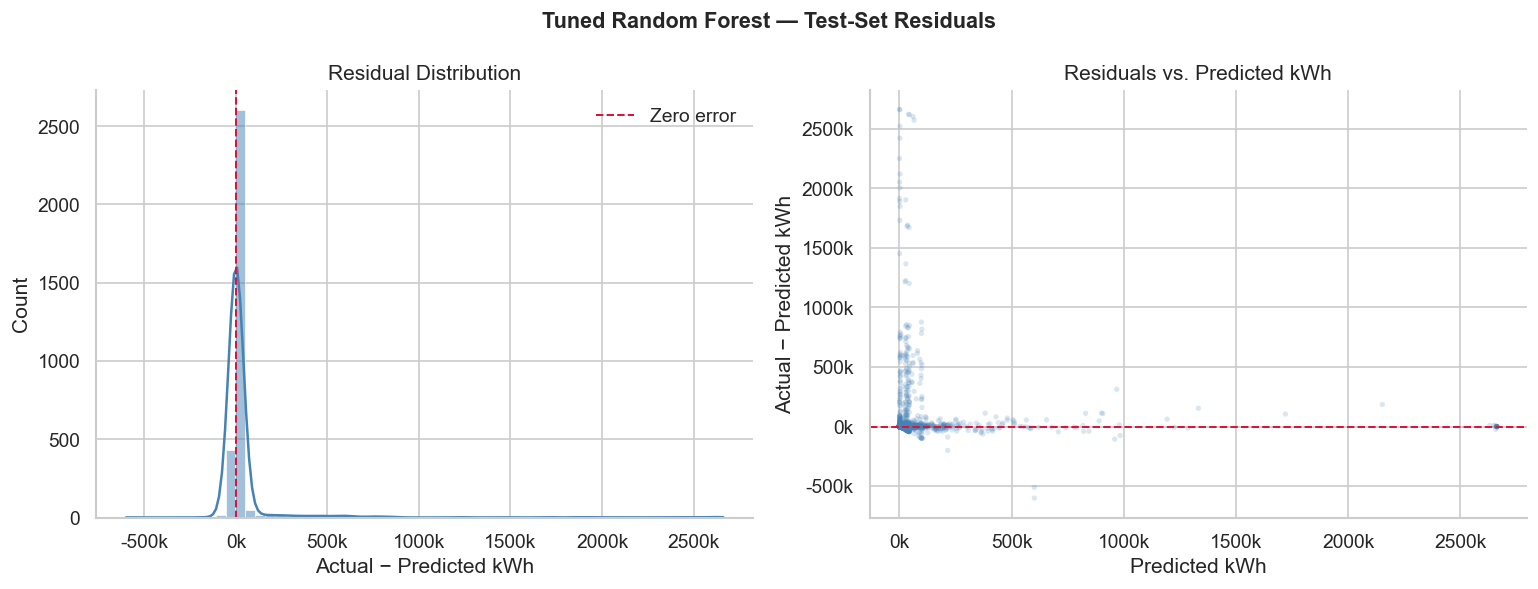

In [20]:
y_test_pred_kwh = np.expm1(best_rf_model.predict(X_test))
y_test_true_kwh = np.expm1(y_test)
residuals = y_test_true_kwh - y_test_pred_kwh

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Tuned Random Forest — Test-Set Residuals", fontsize=13, fontweight="bold")

# Histogram of residuals
sns.histplot(residuals, bins=60, kde=True, ax=axes[0],
             color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].axvline(0, color="crimson", linestyle="--", linewidth=1.2, label="Zero error")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Actual − Predicted kWh")
axes[0].set_ylabel("Count")
axes[0].legend(frameon=False)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

# Residuals vs. predicted
axes[1].scatter(y_test_pred_kwh, residuals, alpha=0.2, s=10,
                color="steelblue", edgecolors="none")
axes[1].axhline(0, color="crimson", linestyle="--", linewidth=1.2)
axes[1].set_title("Residuals vs. Predicted kWh")
axes[1].set_xlabel("Predicted kWh")
axes[1].set_ylabel("Actual − Predicted kWh")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

plt.tight_layout()
plt.show()

## 8. Conclusions and Next Steps

### Key Findings

- Monthly electricity usage and energy intensity are strongly right-skewed; log transforms (`log_kwh`, `log_kwh_per_ft2`) yield much more symmetric distributions appropriate for regression modeling.  
- **Building size** is the dominant driver of consumption: gross floor area and total use area have strong positive relationships with monthly kWh, particularly visible in the log–log scatter plot.  
- **Property type** is highly informative: water/wastewater treatment plants, transportation terminals, and other public-service facilities show substantially higher intensities than offices, libraries, or smaller civic buildings.  
- A clear **seasonal pattern** emerges, with higher average consumption in winter and late summer and lower usage in spring shoulder months.  
- The tuned **Random Forest model** substantially outperforms the Ridge linear baseline. Feature importance confirms that gross floor area, total use area, month, key property types, occupancy, and city/municipality are the strongest predictors.

### Practical Implications

- Portfolio-level energy reductions are most efficiently targeted at large, high-intensity properties (water/wastewater, transport), where per-building savings are greatest.  
- The model can serve as a **benchmarking tool**: comparing a building's actual monthly kWh against its prediction flags anomalously high-consuming months or facilities for further investigation.  
- Tracking detailed use-type allocations (use area and number of use types per property) contributes meaningfully to prediction accuracy, reinforcing the value of thorough data collection.

### Limitations

- The analysis relies solely on Portfolio Manager data and does not include external drivers such as weather (heating/cooling degree-days) or electricity prices, which likely explain a significant portion of the remaining variance.  
- Some data quality issues persist: missing meter start/end dates and incomplete use-area records were flagged or mitigated, but may still affect accuracy for individual buildings.  
- Modeling at the **meter-month** level introduces noise from billing irregularities; aggregating to the property-month or property-year level could yield more stable targets.  
- Random Forest predictions may not extrapolate reliably to building sizes or property types not well-represented in the training data.

### Future Work

- Incorporate **weather variables** (heating/cooling degree-days) and interaction terms (e.g., floor area × cooling degree-days) to capture climate-driven variability.  
- Evaluate gradient-boosted models (XGBoost, LightGBM) against the current Random Forest using the same feature set.  
- Explore separate models for major property-type groups to reduce within-group heterogeneity.  
- Investigate extreme residuals through domain consultation to better understand atypical billing patterns and anomalous operational events.